# YRBSS 2023 Data Analysis

## Purpose

The Youth Risk Behavior Surveillance System (YRBSS) provides self-reported information about adolescent mental health, safety, school experiences, family context, and health behaviors.

For this project, YRBSS adds an adolescent perspective to the pediatric mental health analysis. While NSCH reflects parent-reported child health and care access, YRBSS captures high school students' own reports of emotional distress, suicidality, adverse experiences, school conditions, and protective factors.

The analysis focuses on:

- poor mental health and persistent sadness or hopelessness
- suicidal thoughts and behaviors
- adverse childhood and household experiences
- bullying, school safety, and school connectedness
- family and adult protective factors
- behavioral and lifestyle factors
- demographic differences in mental health outcomes

Because YRBSS uses a complex survey design, survey weights and design fields are retained for interpretation and later weighted analyses.

In [1]:
import pandas as pd
from pathlib import Path

cleaned_dir = Path("../../data/cleaned")

yrbss_path = cleaned_dir / "yrbss_2023_cleaned.csv"

yrbss = pd.read_csv(yrbss_path)

print("Shape:", yrbss.shape)
print()
print("Columns:")
for col in yrbss.columns:
    print(col)

Shape: (17838, 33)

Columns:
age
sex
grade
race_ethnicity
persistent_sadness_hopelessness
considered_suicide
made_suicide_plan
attempted_suicide
suicide_attempt_injury
poor_mental_health
missed_school_due_to_safety
experienced_racism_at_school
bullied_at_school
electronically_bullied
school_connectedness
unfair_discipline_at_school
adult_met_basic_needs
parental_monitoring
physical_activity
sports_team
social_media_use
sleep
weight
stratum
psu
sexual_abuse
emotional_abuse
physical_abuse
witnessed_intimate_partner_violence
household_substance_use
household_poor_mental_health
parent_guardian_incarceration
difficulty_concentrating_remembering_deciding


C:\Users\akila\AppData\Local\Temp\ipykernel_87464\1139043845.py:8: DtypeWarning: Columns (0: poor_mental_health, 1: school_connectedness, 2: unfair_discipline_at_school, 3: parental_monitoring, 4: sports_team, 5: sexual_abuse, 6: emotional_abuse, 7: physical_abuse, 8: witnessed_intimate_partner_violence, 9: household_substance_use, 10: household_poor_mental_health, 11: parent_guardian_incarceration, 12: difficulty_concentrating_remembering_deciding) have mixed types. Specify dtype option on import or set low_memory=False.
  yrbss = pd.read_csv(yrbss_path)


In [2]:
yrbss.head()

,age,sex,grade,race_ethnicity,persistent_sadness_hopelessness,considered_suicide,made_suicide_plan,attempted_suicide,suicide_attempt_injury,poor_mental_health,...,stratum,psu,sexual_abuse,emotional_abuse,physical_abuse,witnessed_intimate_partner_violence,household_substance_use,household_poor_mental_health,parent_guardian_incarceration,difficulty_concentrating_remembering_deciding
0,14 years old,Female,9th grade,NaN,Yes,No,No,0 times,Did not attempt suicide,Never,...,103,16294,No,NaN,Never,Never,No,Yes,No,No
1,15 years old,Male,9th grade,White,No,No,No,0 times,Did not attempt suicide,Sometimes,...,103,16294,No,Rarely,Rarely,Rarely,No,No,No,Yes
2,16 years old,Male,11th grade,White,Yes,No,No,0 times,Did not attempt suicide,Rarely,...,103,16294,No,Sometimes,Rarely,Rarely,No,No,Yes,No
3,17 years old,Female,10th grade,White,Yes,No,No,0 times,Did not attempt suicide,Sometimes,...,103,16294,Yes,Never,Never,Never,No,No,No,Yes
4,14 years old,Male,9th grade,White,Yes,No,Yes,0 times,Did not attempt suicide,Sometimes,...,103,16294,No,Never,Never,Never,No,No,No,No


In [3]:
yrbss.info()

<class 'pandas.DataFrame'>
RangeIndex: 17838 entries, 0 to 17837
Data columns (total 33 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   age                                            17838 non-null  str    
 1   sex                                            17696 non-null  str    
 2   grade                                          17679 non-null  str    
 3   race_ethnicity                                 17526 non-null  str    
 4   persistent_sadness_hopelessness                17640 non-null  str    
 5   considered_suicide                             17464 non-null  str    
 6   made_suicide_plan                              16321 non-null  str    
 7   attempted_suicide                              17146 non-null  str    
 8   suicide_attempt_injury                         12816 non-null  str    
 9   poor_mental_health                             13867 non-null

In [5]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency

## 1. Load and Validate the Cleaned Dataset

The cleaned YRBSS dataset is loaded below. Basic checks are performed to confirm the dataset dimensions, column names, and overall structure before beginning exploratory analysis.

In [8]:
file_path = "C:\\Users\\akila\\pediatric-mental-health-analysis\\data\\cleaned\\yrbss_2023_cleaned.csv"

yrbss = pd.read_csv(file_path)

print("Dataset shape:", yrbss.shape)
print("\nColumns:")
print(yrbss.columns.tolist())

yrbss.head()

Dataset shape: (17838, 33)

Columns:
['age', 'sex', 'grade', 'race_ethnicity', 'persistent_sadness_hopelessness', 'considered_suicide', 'made_suicide_plan', 'attempted_suicide', 'suicide_attempt_injury', 'poor_mental_health', 'missed_school_due_to_safety', 'experienced_racism_at_school', 'bullied_at_school', 'electronically_bullied', 'school_connectedness', 'unfair_discipline_at_school', 'adult_met_basic_needs', 'parental_monitoring', 'physical_activity', 'sports_team', 'social_media_use', 'sleep', 'weight', 'stratum', 'psu', 'sexual_abuse', 'emotional_abuse', 'physical_abuse', 'witnessed_intimate_partner_violence', 'household_substance_use', 'household_poor_mental_health', 'parent_guardian_incarceration', 'difficulty_concentrating_remembering_deciding']


C:\Users\akila\AppData\Local\Temp\ipykernel_87464\523500028.py:3: DtypeWarning: Columns (0: poor_mental_health, 1: school_connectedness, 2: unfair_discipline_at_school, 3: parental_monitoring, 4: sports_team, 5: sexual_abuse, 6: emotional_abuse, 7: physical_abuse, 8: witnessed_intimate_partner_violence, 9: household_substance_use, 10: household_poor_mental_health, 11: parent_guardian_incarceration, 12: difficulty_concentrating_remembering_deciding) have mixed types. Specify dtype option on import or set low_memory=False.
  yrbss = pd.read_csv(file_path)


,age,sex,grade,race_ethnicity,persistent_sadness_hopelessness,considered_suicide,made_suicide_plan,attempted_suicide,suicide_attempt_injury,poor_mental_health,...,stratum,psu,sexual_abuse,emotional_abuse,physical_abuse,witnessed_intimate_partner_violence,household_substance_use,household_poor_mental_health,parent_guardian_incarceration,difficulty_concentrating_remembering_deciding
0,14 years old,Female,9th grade,NaN,Yes,No,No,0 times,Did not attempt suicide,Never,...,103,16294,No,NaN,Never,Never,No,Yes,No,No
1,15 years old,Male,9th grade,White,No,No,No,0 times,Did not attempt suicide,Sometimes,...,103,16294,No,Rarely,Rarely,Rarely,No,No,No,Yes
2,16 years old,Male,11th grade,White,Yes,No,No,0 times,Did not attempt suicide,Rarely,...,103,16294,No,Sometimes,Rarely,Rarely,No,No,Yes,No
3,17 years old,Female,10th grade,White,Yes,No,No,0 times,Did not attempt suicide,Sometimes,...,103,16294,Yes,Never,Never,Never,No,No,No,Yes
4,14 years old,Male,9th grade,White,Yes,No,Yes,0 times,Did not attempt suicide,Sometimes,...,103,16294,No,Never,Never,Never,No,No,No,No


## Exploratory Data Analysis

This section examines the distribution of the analysis sample and key adolescent mental health outcomes before testing relationships between mental health and potential risk or protective factors.

In [9]:
# Basic dataset summary

print("Number of respondents:", len(yrbss))
print("Number of variables:", yrbss.shape[1])

print("\nMissing values by variable:")
missing_summary = (
    yrbss.isna()
    .sum()
    .sort_values(ascending=False)
)

missing_summary

Number of respondents: 17838
Number of variables: 33

Missing values by variable:


unfair_discipline_at_school                      8688
parental_monitoring                              8454
difficulty_concentrating_remembering_deciding    8375
school_connectedness                             8158
sports_team                                      6578
household_substance_use                          6166
household_poor_mental_health                     6102
parent_guardian_incarceration                    6079
witnessed_intimate_partner_violence              5724
sexual_abuse                                     5668
physical_abuse                                   5587
emotional_abuse                                  5584
suicide_attempt_injury                           5022
social_media_use                                 4462
poor_mental_health                               3971
adult_met_basic_needs                            3857
sleep                                            2346
experienced_racism_at_school                     1600
made_suicide_plan           

### Missing Data Interpretation

Missingness varies substantially across variables. Several school, family, household, and adverse-experience measures have large numbers of missing responses because not all YRBSS questions were administered to every respondent.

Core demographic variables and several primary mental-health outcomes have relatively high completeness, while analyses involving variables with greater missingness will use the available valid responses for those specific measures.

Missing values will therefore be handled on an analysis-by-analysis basis rather than removing respondents with any missing data across the full dataset.

### Sample Characteristics

The distributions of age, sex, grade, and race/ethnicity are examined to describe the adolescent sample before analyzing mental-health outcomes.

In [11]:
demographic_vars = [
    "age",
    "sex",
    "grade",
    "race_ethnicity"
]

for col in demographic_vars:
    print(f"\n--- {col} ---")
    print(yrbss[col].value_counts(dropna=False))


--- age ---
age
15 years old               5526
16 years old               5208
17 years old               4458
14 years old               2569
12 years old or younger      44
13 years old                 33
Name: count, dtype: int64

--- sex ---
sex
Female    8887
Male      8809
NaN        142
Name: count, dtype: int64

--- grade ---
grade
9th grade                  5659
10th grade                 5374
11th grade                 4647
12th grade                 1962
NaN                         159
Ungraded or other grade      37
Name: count, dtype: int64

--- race_ethnicity ---
race_ethnicity
White                                        8600
Multiple race - Hispanic                     2466
Multiple race - Non-Hispanic                 1626
Black or African American                    1595
American Indian or Alaska Native             1128
Hispanic/Latino                              1119
Asian                                         897
NaN                                           312

### Sample Characteristics Interpretation

The analysis sample includes 17,838 adolescents and is concentrated primarily among respondents ages 15 to 17. The sex distribution is nearly even between female and male respondents.

Most respondents are enrolled in grades 9 through 11, while the number of 12th-grade respondents is smaller. The sample includes adolescents from multiple racial and ethnic groups, with White respondents representing the largest group.

Missing demographic information is relatively limited, allowing these variables to be used for subgroup comparisons later in the analysis.

### Mental Health and Suicidality Outcomes

The distributions of key mental-health and suicidality measures are examined to establish the prevalence and severity of adolescent mental-health concerns in the analysis sample.

In [12]:
mental_health_vars = [
    "persistent_sadness_hopelessness",
    "poor_mental_health",
    "considered_suicide",
    "made_suicide_plan",
    "attempted_suicide",
    "suicide_attempt_injury"
]

for col in mental_health_vars:
    print(f"\n--- {col} ---")
    print(yrbss[col].value_counts(dropna=False))


--- persistent_sadness_hopelessness ---
persistent_sadness_hopelessness
No     10457
Yes     7183
NaN      198
Name: count, dtype: int64

--- poor_mental_health ---
poor_mental_health
Sometimes           4172
NaN                 3971
Most of the time    3006
Rarely              2931
Never               2479
Always              1279
Name: count, dtype: int64

--- considered_suicide ---
considered_suicide
No     13739
Yes     3725
NaN      374
Name: count, dtype: int64

--- made_suicide_plan ---
made_suicide_plan
No     13471
Yes     2850
NaN     1517
Name: count, dtype: int64

--- attempted_suicide ---
attempted_suicide
0 times            15371
1 time               982
NaN                  692
2 or 3 times         566
6 or more times      134
4 or 5 times          93
Name: count, dtype: int64

--- suicide_attempt_injury ---
suicide_attempt_injury
Did not attempt suicide    11509
NaN                         5022
No                           981
Yes                          326
Name: cou

### Mental Health Outcome Interpretation

Mental-health concerns were common among respondents with valid responses. Approximately 40.7% reported persistent sadness or hopelessness, while 21.3% reported seriously considering suicide and 17.5% reported making a suicide plan.

Approximately 10.4% of respondents with valid suicide-attempt data reported at least one suicide attempt. The broader poor-mental-health measure also showed substantial variation, with respondents reporting experiences ranging from never to always.

Because missingness differs across YRBSS measures, percentages are calculated using the valid responses available for each individual question rather than the full analysis sample.

### Prevalence of Key Mental Health Outcomes

Valid-response percentages are calculated for the primary binary mental-health and suicidality outcomes to make comparisons across measures easier to interpret.

In [13]:
# Calculate prevalence among valid responses

binary_outcomes = {
    "Persistent sadness or hopelessness": "persistent_sadness_hopelessness",
    "Seriously considered suicide": "considered_suicide",
    "Made a suicide plan": "made_suicide_plan"
}

prevalence_results = []

for label, col in binary_outcomes.items():
    valid = yrbss[col].dropna()
    yes_count = (valid == "Yes").sum()
    valid_n = len(valid)
    percent = (yes_count / valid_n) * 100

    prevalence_results.append({
        "Outcome": label,
        "Yes (n)": yes_count,
        "Valid responses (n)": valid_n,
        "Percent": round(percent, 1)
    })

# Suicide attempt requires a separate calculation because it is multi-category
attempt_valid = yrbss["attempted_suicide"].dropna()
attempt_count = (attempt_valid != "0 times").sum()
attempt_percent = (attempt_count / len(attempt_valid)) * 100

prevalence_results.append({
    "Outcome": "Attempted suicide at least once",
    "Yes (n)": attempt_count,
    "Valid responses (n)": len(attempt_valid),
    "Percent": round(attempt_percent, 1)
})

prevalence_df = pd.DataFrame(prevalence_results)

prevalence_df

,Outcome,Yes (n),Valid responses (n),Percent
0,Persistent sadness or hopelessness,7183,17640,40.7
1,Seriously considered suicide,3725,17464,21.3
2,Made a suicide plan,2850,16321,17.5
3,Attempted suicide at least once,1775,17146,10.4


### Mental Health Outcomes by Age

Mental-health outcomes are compared across age groups to examine whether reported sadness, suicidality, and suicide attempts vary across adolescence.

In [14]:
age_outcomes = [
    "persistent_sadness_hopelessness",
    "considered_suicide",
    "made_suicide_plan"
]

for col in age_outcomes:
    age_table = pd.crosstab(
        yrbss["age"],
        yrbss[col],
        normalize="index"
    ) * 100

    print(f"\n--- {col} by age (%) ---")
    print(age_table.round(1))


--- persistent_sadness_hopelessness by age (%) ---
persistent_sadness_hopelessness    No   Yes
age                                        
12 years old or younger          40.5  59.5
13 years old                     86.7  13.3
14 years old                     61.7  38.3
15 years old                     60.0  40.0
16 years old                     59.0  41.0
17 years old                     57.4  42.6

--- considered_suicide by age (%) ---
considered_suicide         No   Yes
age                                
12 years old or younger  40.0  60.0
13 years old             87.1  12.9
14 years old             79.1  20.9
15 years old             79.2  20.8
16 years old             77.6  22.4
17 years old             79.3  20.7

--- made_suicide_plan by age (%) ---
made_suicide_plan          No   Yes
age                                
12 years old or younger  54.8  45.2
13 years old             92.0   8.0
14 years old             83.2  16.8
15 years old             82.2  17.8
16 years old   

In [15]:
attempt_age = yrbss[["age", "attempted_suicide"]].dropna().copy()

attempt_age["attempted_at_least_once"] = (
    attempt_age["attempted_suicide"] != "0 times"
)

attempt_age_table = (
    attempt_age.groupby("age")["attempted_at_least_once"]
    .mean()
    .mul(100)
    .round(1)
)

print("\n--- Attempted suicide at least once by age (%) ---")
print(attempt_age_table)


--- Attempted suicide at least once by age (%) ---
age
12 years old or younger    57.9
13 years old               16.1
14 years old               10.2
15 years old               10.4
16 years old               10.9
17 years old                9.2
Name: attempted_at_least_once, dtype: float64


### Age Comparison Interpretation

Mental-health outcomes were relatively consistent across the larger age groups from ages 14 through 17. Persistent sadness or hopelessness increased gradually from 38.3% at age 14 to 42.6% at age 17, while suicidal ideation and suicide-plan prevalence remained broadly similar across these ages.

The very high percentages observed among respondents age 12 or younger should not be interpreted as evidence of substantially greater mental-health risk because this age group contains very few respondents. Percentages based on small groups are unstable and can change substantially with only a few responses.

For this reason, subgroup sample sizes are considered alongside percentages when interpreting age differences.

In [16]:
# Show valid sample size and positive-response percentage by age

for col in age_outcomes:
    temp = yrbss[["age", col]].dropna()

    age_summary = (
        temp.groupby("age")[col]
        .agg(
            valid_n="count",
            yes_n=lambda x: (x == "Yes").sum()
        )
    )

    age_summary["yes_percent"] = (
        age_summary["yes_n"] / age_summary["valid_n"] * 100
    ).round(1)

    print(f"\n--- {col} by age ---")
    print(age_summary)


--- persistent_sadness_hopelessness by age ---
                         valid_n  yes_n  yes_percent
age                                                 
12 years old or younger       42     25         59.5
13 years old                  30      4         13.3
14 years old                2539    973         38.3
15 years old                5462   2184         40.0
16 years old                5144   2111         41.0
17 years old                4423   1886         42.6

--- considered_suicide by age ---
                         valid_n  yes_n  yes_percent
age                                                 
12 years old or younger       40     24         60.0
13 years old                  31      4         12.9
14 years old                2507    524         20.9
15 years old                5403   1125         20.8
16 years old                5103   1141         22.4
17 years old                4380    907         20.7

--- made_suicide_plan by age ---
                         valid_n  y

### Mental Health Outcomes by Sex

Mental-health outcomes are compared by respondent sex to examine whether the prevalence of persistent sadness, suicidal ideation, suicide planning, and suicide attempts differs between female and male adolescents.

In [17]:
for col in age_outcomes:
    sex_table = pd.crosstab(
        yrbss["sex"],
        yrbss[col],
        normalize="index"
    ) * 100

    print(f"\n--- {col} by sex (%) ---")
    print(sex_table.round(1))


--- persistent_sadness_hopelessness by sex (%) ---
persistent_sadness_hopelessness    No   Yes
sex                                        
Female                           47.1  52.9
Male                             71.7  28.3

--- considered_suicide by sex (%) ---
considered_suicide    No   Yes
sex                           
Female              72.1  27.9
Male                85.5  14.5

--- made_suicide_plan by sex (%) ---
made_suicide_plan    No   Yes
sex                          
Female             77.3  22.7
Male               87.9  12.1


In [19]:
attempt_sex = yrbss[["sex", "attempted_suicide"]].dropna().copy()

attempt_sex["attempted_at_least_once"] = (
    attempt_sex["attempted_suicide"] != "0 times"
)

attempt_sex_table = (
    attempt_sex.groupby("sex")["attempted_at_least_once"]
    .mean()
    .mul(100)
    .round(1)
)

print("\n--- Attempted suicide at least once by sex (%) ---")
print(attempt_sex_table)


--- Attempted suicide at least once by sex (%) ---
sex
Female    13.7
Male       6.9
Name: attempted_at_least_once, dtype: float64


### Sex Comparison Interpretation

Mental-health outcomes differed substantially by sex. Female respondents reported persistent sadness or hopelessness at nearly twice the rate of male respondents, 52.9% compared with 28.3%.

Female respondents also reported higher levels of suicidality. Approximately 27.9% of female respondents seriously considered suicide compared with 14.5% of male respondents, while 22.7% of female respondents reported making a suicide plan compared with 12.1% of male respondents.

Suicide attempts followed a similar pattern, with 13.7% of female respondents reporting at least one attempt compared with 6.9% of male respondents.

These descriptive differences suggest that sex may be an important factor associated with adolescent mental-health outcomes and should be examined statistically later in the analysis.

### Adverse Childhood Experiences and Household Adversity

This section examines the prevalence of adverse childhood experiences and household adversity among respondents. These factors are later compared with adolescent mental-health outcomes to assess whether exposure is associated with persistent sadness, suicidality, and suicide attempts.

In [20]:
ace_vars = [
    "sexual_abuse",
    "emotional_abuse",
    "physical_abuse",
    "witnessed_intimate_partner_violence",
    "household_substance_use",
    "household_poor_mental_health",
    "parent_guardian_incarceration"
]

for col in ace_vars:
    print(f"\n--- {col} ---")
    print(yrbss[col].value_counts(dropna=False))


--- sexual_abuse ---
sexual_abuse
No     11155
NaN     5668
Yes     1015
Name: count, dtype: int64

--- emotional_abuse ---
emotional_abuse
NaN                 5584
Never               4728
Rarely              3198
Sometimes           2760
Most of the time    1093
Always               475
Name: count, dtype: int64

--- physical_abuse ---
physical_abuse
Never               8276
NaN                 5587
Rarely              2465
Sometimes           1169
Most of the time     231
Always               110
Name: count, dtype: int64

--- witnessed_intimate_partner_violence ---
witnessed_intimate_partner_violence
Never               9482
NaN                 5724
Rarely              1513
Sometimes            813
Most of the time     213
Always                93
Name: count, dtype: int64

--- household_substance_use ---
household_substance_use
No     8297
NaN    6166
Yes    3375
Name: count, dtype: int64

--- household_poor_mental_health ---
household_poor_mental_health
No     7961
NaN    6102
Y

### School and Peer Environment

School and peer experiences are examined as potential social and environmental factors related to adolescent mental health.

In [21]:
school_peer_vars = [
    "bullied_at_school",
    "electronically_bullied",
    "missed_school_due_to_safety",
    "experienced_racism_at_school",
    "unfair_discipline_at_school",
    "school_connectedness",
    "social_media_use"
]

for col in school_peer_vars:
    print(f"\n--- {col} ---")
    print(yrbss[col].value_counts(dropna=False))


--- bullied_at_school ---
bullied_at_school
No     13990
Yes     3675
NaN      173
Name: count, dtype: int64

--- electronically_bullied ---
electronically_bullied
No     14581
Yes     3083
NaN      174
Name: count, dtype: int64

--- missed_school_due_to_safety ---
missed_school_due_to_safety
0 days            14815
1 day               994
NaN                 992
2 or 3 days         592
6 or more days      293
4 or 5 days         152
Name: count, dtype: int64

--- experienced_racism_at_school ---
experienced_racism_at_school
Never               11082
Rarely               2559
Sometimes            1807
NaN                  1600
Most of the time      420
Always                370
Name: count, dtype: int64

--- unfair_discipline_at_school ---
unfair_discipline_at_school
NaN    8688
No     7204
Yes    1946
Name: count, dtype: int64

--- school_connectedness ---
school_connectedness
NaN                  8158
Agree                3841
Not sure             2403
Strongly agree       1432
Disa

### Protective and Behavioral Factors

Potential protective and behavioral factors are examined to understand conditions that may be associated with better or worse adolescent mental-health outcomes.

In [22]:
protective_vars = [
    "adult_met_basic_needs",
    "parental_monitoring",
    "sleep",
    "physical_activity",
    "sports_team"
]

for col in protective_vars:
    print(f"\n--- {col} ---")
    print(yrbss[col].value_counts(dropna=False))


--- adult_met_basic_needs ---
adult_met_basic_needs
Always              10335
NaN                  3857
Most of the time     1751
Never                 895
Sometimes             622
Rarely                378
Name: count, dtype: int64

--- parental_monitoring ---
parental_monitoring
NaN                 8454
Always              4638
Most of the time    3264
Sometimes            797
Rarely               387
Never                298
Name: count, dtype: int64

--- sleep ---
sleep
7 hours             4338
6 hours             3819
8 hours             2721
NaN                 2346
5 hours             2229
4 or less hours     1465
9 hours              683
10 or more hours     237
Name: count, dtype: int64

--- physical_activity ---
physical_activity
7 days    4300
0 days    2467
5 days    2376
3 days    1873
4 days    1692
2 days    1524
6 days    1367
1 day     1166
NaN       1073
Name: count, dtype: int64

--- sports_team ---
sports_team
NaN                6578
0 teams            5387
1 team

### Persistent Sadness or Hopelessness Across Risk and Protective Factors

Persistent sadness or hopelessness is used as an initial mental-health outcome to examine how adolescent mental health varies across adverse experiences, school and peer conditions, and potentially protective factors.

Percentages are calculated among respondents with valid responses for both the mental-health outcome and the factor being examined.

In [23]:
binary_factor_vars = [
    "sexual_abuse",
    "household_substance_use",
    "household_poor_mental_health",
    "parent_guardian_incarceration",
    "bullied_at_school",
    "electronically_bullied",
    "unfair_discipline_at_school"
]

for factor in binary_factor_vars:
    temp = yrbss[[factor, "persistent_sadness_hopelessness"]].dropna()

    table = pd.crosstab(
        temp[factor],
        temp["persistent_sadness_hopelessness"],
        normalize="index"
    ) * 100

    print(f"\n--- Persistent sadness/hopelessness by {factor} (%) ---")
    print(table.round(1))
    print("Valid n:", len(temp))


--- Persistent sadness/hopelessness by sexual_abuse (%) ---
persistent_sadness_hopelessness    No   Yes
sexual_abuse                               
No                               61.0  39.0
Yes                              21.6  78.4
Valid n: 12064

--- Persistent sadness/hopelessness by household_substance_use (%) ---
persistent_sadness_hopelessness    No   Yes
household_substance_use                    
No                               65.8  34.2
Yes                              35.8  64.2
Valid n: 11580

--- Persistent sadness/hopelessness by household_poor_mental_health (%) ---
persistent_sadness_hopelessness    No   Yes
household_poor_mental_health               
No                               68.7  31.3
Yes                              33.2  66.8
Valid n: 11641

--- Persistent sadness/hopelessness by parent_guardian_incarceration (%) ---
persistent_sadness_hopelessness    No   Yes
parent_guardian_incarceration              
No                               61.0  39.0
Yes    

### Binary Risk Factor Interpretation

Persistent sadness or hopelessness was substantially more common among adolescents reporting several adverse experiences.

The largest descriptive differences were observed for sexual abuse, electronic bullying, household poor mental health, bullying at school, and household substance use. For example, 78.4% of respondents reporting sexual abuse also reported persistent sadness or hopelessness, compared with 39.0% of respondents who did not report sexual abuse. Similarly, persistent sadness or hopelessness was reported by 70.4% of adolescents who experienced electronic bullying compared with 34.4% of those who did not.

Higher prevalence was also observed among adolescents reporting household poor mental health, bullying at school, household substance use, parent or guardian incarceration, and unfair school discipline.

These descriptive comparisons indicate potential associations but do not establish causation. Statistical tests are used later to assess the strength and significance of these relationships.

### Persistent Sadness or Hopelessness Across Ordered Risk and Protective Factors

Several YRBSS measures contain ordered response categories that preserve information about frequency, intensity, or degree of exposure. These variables are examined without collapsing their response categories to identify whether persistent sadness or hopelessness changes systematically across levels of risk or protection.

In [24]:
ordered_factor_vars = [
    "emotional_abuse",
    "physical_abuse",
    "witnessed_intimate_partner_violence",
    "missed_school_due_to_safety",
    "experienced_racism_at_school",
    "school_connectedness",
    "adult_met_basic_needs",
    "parental_monitoring",
    "sleep",
    "physical_activity",
    "sports_team"
]

for factor in ordered_factor_vars:
    temp = yrbss[[factor, "persistent_sadness_hopelessness"]].dropna()

    table = pd.crosstab(
        temp[factor],
        temp["persistent_sadness_hopelessness"],
        normalize="index"
    ) * 100

    print(f"\n--- Persistent sadness/hopelessness by {factor} (%) ---")

    if "Yes" in table.columns:
        print(table[["Yes"]].round(1))
    else:
        print(table.round(1))

    print("Valid n:", len(temp))


--- Persistent sadness/hopelessness by emotional_abuse (%) ---
persistent_sadness_hopelessness   Yes
emotional_abuse                      
Always                           80.0
Most of the time                 79.8
Never                            21.4
Rarely                           40.5
Sometimes                        60.4
Valid n: 12143

--- Persistent sadness/hopelessness by physical_abuse (%) ---
persistent_sadness_hopelessness   Yes
physical_abuse                       
Always                           70.5
Most of the time                 77.7
Never                            34.1
Rarely                           55.7
Sometimes                        67.4
Valid n: 12143

--- Persistent sadness/hopelessness by witnessed_intimate_partner_violence (%) ---
persistent_sadness_hopelessness       Yes
witnessed_intimate_partner_violence      
Always                               70.7
Most of the time                     79.2
Never                                35.9
Rarely           

### Ordered Risk and Protective Factor Interpretation

Several ordered risk and protective factors showed clear gradients in persistent sadness or hopelessness.

More frequent emotional abuse, physical abuse, exposure to intimate partner violence, and school absence due to safety concerns were generally associated with progressively higher levels of persistent sadness or hopelessness. School connectedness showed a similarly strong pattern in the opposite direction: 33.5% of respondents who strongly agreed that they felt connected at school reported persistent sadness or hopelessness, compared with 70.2% of respondents who strongly disagreed.

Behavioral factors also showed notable gradients. Persistent sadness or hopelessness declined from 64.1% among respondents reporting four or fewer hours of sleep to 25.2% among those reporting eight hours. Greater physical activity and participation on more sports teams were also associated with progressively lower prevalence of persistent sadness or hopelessness.

Not all ordered variables followed a consistent gradient. Adult basic-needs support and parental monitoring showed less uniform patterns across response categories and should therefore be interpreted cautiously and examined further before drawing conclusions.

These findings are descriptive and do not establish causal relationships.

## 3. Statistical Analysis

Statistical tests are used to evaluate whether the descriptive relationships observed during exploratory analysis are unlikely to be explained by random variation alone.

Because the primary YRBSS variables analyzed here are categorical, chi-square tests of independence are used to evaluate associations between mental-health outcomes and selected demographic, adverse-experience, school, and behavioral factors. Cramér's V is calculated alongside each chi-square test to estimate the strength of the association.

In [25]:
test_factors = [
    "sex",
    "sexual_abuse",
    "emotional_abuse",
    "household_poor_mental_health",
    "bullied_at_school",
    "electronically_bullied",
    "school_connectedness",
    "sleep",
    "physical_activity",
    "sports_team"
]

### Chi-Square Tests and Cramér's V

Chi-square tests of independence are used to evaluate whether selected demographic, adverse-experience, school, and behavioral factors are statistically associated with persistent sadness or hopelessness.

Because statistical significance can be influenced by large sample sizes, Cramér's V is also calculated to estimate the strength of each association.

In [26]:
from scipy.stats import chi2_contingency
import numpy as np
import pandas as pd

test_factors = [
    "sex",
    "sexual_abuse",
    "emotional_abuse",
    "household_poor_mental_health",
    "bullied_at_school",
    "electronically_bullied",
    "school_connectedness",
    "sleep",
    "physical_activity",
    "sports_team"
]

outcome = "persistent_sadness_hopelessness"

results = []

for factor in test_factors:

    # Keep only valid responses for the factor and outcome
    temp = yrbss[[factor, outcome]].dropna()

    # Create contingency table
    contingency_table = pd.crosstab(
        temp[factor],
        temp[outcome]
    )

    # Chi-square test
    chi2, p, dof, expected = chi2_contingency(contingency_table)

    # Cramér's V
    n = contingency_table.to_numpy().sum()
    min_dim = min(contingency_table.shape) - 1

    if min_dim > 0:
        cramers_v = np.sqrt(chi2 / (n * min_dim))
    else:
        cramers_v = np.nan

    results.append({
        "Factor": factor,
        "Valid N": n,
        "Chi-square": round(chi2, 2),
        "df": dof,
        "p-value": p,
        "Cramer's V": round(cramers_v, 3)
    })

chi_square_results = pd.DataFrame(results)

# Rank strongest associations first
chi_square_results = chi_square_results.sort_values(
    "Cramer's V",
    ascending=False
).reset_index(drop=True)

chi_square_results

,Factor,Valid N,Chi-square,df,p-value,Cramer's V
0,emotional_abuse,12143,2103.13,4,0.000000e+00,0.416
1,household_poor_mental_health,11641,1312.33,1,2.359306e-287,0.336
2,electronically_bullied,17510,1350.97,1,9.459492e-296,0.278
3,bullied_at_school,17502,1177.68,1,4.325872e-258,0.259
4,sleep,15344,970.01,6,2.731093e-206,0.251
5,sex,17508,1095.03,1,3.971629e-240,0.250
6,school_connectedness,9592,505.07,4,5.365855e-108,0.229
7,sexual_abuse,12064,585.55,1,2.323859e-129,0.220
8,physical_activity,16612,325.65,7,2.001192e-66,0.140
9,sports_team,11132,148.59,3,5.310726e-32,0.116


### Associations Across Multiple Mental Health Outcomes

The selected risk and protective factors are tested across multiple adolescent mental-health outcomes to determine whether the strongest associations observed for persistent sadness or hopelessness are also present for suicidal ideation, suicide planning, and suicide attempts.

In [27]:
outcomes_to_test = [
    "persistent_sadness_hopelessness",
    "considered_suicide",
    "made_suicide_plan"
]

all_results = []

for outcome in outcomes_to_test:

    for factor in test_factors:

        temp = yrbss[[factor, outcome]].dropna()

        contingency_table = pd.crosstab(
            temp[factor],
            temp[outcome]
        )

        chi2, p, dof, expected = chi2_contingency(contingency_table)

        n = contingency_table.to_numpy().sum()
        min_dim = min(contingency_table.shape) - 1

        if min_dim > 0:
            cramers_v = np.sqrt(chi2 / (n * min_dim))
        else:
            cramers_v = np.nan

        all_results.append({
            "Outcome": outcome,
            "Factor": factor,
            "Valid N": n,
            "Chi-square": round(chi2, 2),
            "df": dof,
            "p-value": p,
            "Cramer's V": round(cramers_v, 3)
        })

all_outcome_results = pd.DataFrame(all_results)

all_outcome_results = all_outcome_results.sort_values(
    ["Outcome", "Cramer's V"],
    ascending=[True, False]
).reset_index(drop=True)

all_outcome_results

,Outcome,Factor,Valid N,Chi-square,df,p-value,Cramer's V
0,considered_suicide,emotional_abuse,12003,1802.52,4,0.000000e+00,0.388
1,considered_suicide,household_poor_mental_health,11498,1069.96,1,1.116825e-234,0.305
2,considered_suicide,electronically_bullied,17341,1278.06,1,6.608697e-280,0.271
3,considered_suicide,bullied_at_school,17360,1221.01,1,1.655225e-267,0.265
4,considered_suicide,sexual_abuse,11923,812.50,1,1.033212e-178,0.261
5,considered_suicide,sleep,15231,691.68,6,3.826708e-146,0.213
6,considered_suicide,school_connectedness,9543,373.62,4,1.387714e-79,0.198
7,considered_suicide,sex,17342,459.98,1,4.856438e-102,0.163
8,considered_suicide,physical_activity,16478,173.64,7,4.283629e-34,0.103
9,considered_suicide,sports_team,11040,73.12,3,9.151352e-16,0.081


### Multiple-Outcome Statistical Interpretation

The statistical results showed consistent associations between adolescent mental-health outcomes and several adverse experiences.

Emotional abuse had the strongest association across persistent sadness or hopelessness, serious consideration of suicide, and making a suicide plan. Household poor mental health, electronic bullying, bullying at school, and sexual abuse also showed comparatively strong and consistent associations across outcomes.

Sleep and school connectedness were significantly associated with all three mental-health outcomes and showed moderate relationships, particularly with persistent sadness or hopelessness. Physical activity and sports participation were also statistically significant but had smaller effect sizes.

Because nearly all tested relationships were statistically significant in this large sample, Cramér's V provides a more useful comparison of their relative strength than p-values alone.

In [29]:
# Create binary suicide-attempt outcome

yrbss["attempted_at_least_once"] = pd.NA

yrbss.loc[
    yrbss["attempted_suicide"] == "0 times",
    "attempted_at_least_once"
] = "No"

yrbss.loc[
    yrbss["attempted_suicide"].notna()
    & (yrbss["attempted_suicide"] != "0 times"),
    "attempted_at_least_once"
] = "Yes"

In [30]:
attempt_results = []

for factor in test_factors:

    temp = yrbss[[factor, "attempted_at_least_once"]].dropna()

    contingency_table = pd.crosstab(
        temp[factor],
        temp["attempted_at_least_once"]
    )

    chi2, p, dof, expected = chi2_contingency(contingency_table)

    n = contingency_table.to_numpy().sum()
    min_dim = min(contingency_table.shape) - 1

    if min_dim > 0:
        cramers_v = np.sqrt(chi2 / (n * min_dim))
    else:
        cramers_v = np.nan

    attempt_results.append({
        "Factor": factor,
        "Valid N": n,
        "Chi-square": round(chi2, 2),
        "df": dof,
        "p-value": p,
        "Cramer's V": round(cramers_v, 3)
    })

attempt_results_df = pd.DataFrame(attempt_results)

attempt_results_df = attempt_results_df.sort_values(
    "Cramer's V",
    ascending=False
).reset_index(drop=True)

attempt_results_df

,Factor,Valid N,Chi-square,df,p-value,Cramer's V
0,emotional_abuse,12037,1069.39,4,3.267889e-230,0.298
1,sexual_abuse,12029,844.51,1,1.132561e-185,0.265
2,electronically_bullied,17021,958.31,1,2.068225e-210,0.237
3,household_poor_mental_health,11551,554.06,1,1.645738e-122,0.219
4,bullied_at_school,17011,660.56,1,1.127720e-145,0.197
5,sleep,14944,548.19,6,3.473450e-115,0.192
6,school_connectedness,9519,227.64,4,4.250488e-48,0.155
7,sex,17016,212.87,1,3.251717e-48,0.112
8,physical_activity,16161,110.81,7,6.227351e-21,0.083
9,sports_team,10959,17.61,3,5.284603e-04,0.040


### Suicide Attempt Statistical Interpretation

Suicide attempts showed a pattern similar to the other mental-health outcomes. Emotional abuse had the strongest association with attempting suicide at least once, followed by sexual abuse, electronic bullying, household poor mental health, and bullying at school.

Sleep and school connectedness were also significantly associated with suicide attempts, although their effect sizes were smaller than those observed for the strongest adverse-experience variables.

Physical activity and sports-team participation showed comparatively weak associations with suicide attempts despite reaching statistical significance.

Overall, the findings suggest that adverse childhood experiences, household mental-health conditions, and bullying are more strongly associated with severe adolescent mental-health outcomes than the behavioral factors examined here.

### Association Strength Heatmap

A heatmap of Cramér's V values is used to compare the relative strength of associations between selected risk and protective factors and adolescent mental-health outcomes.

Because the variables examined are primarily categorical, Cramér's V is used rather than a traditional Pearson correlation coefficient.

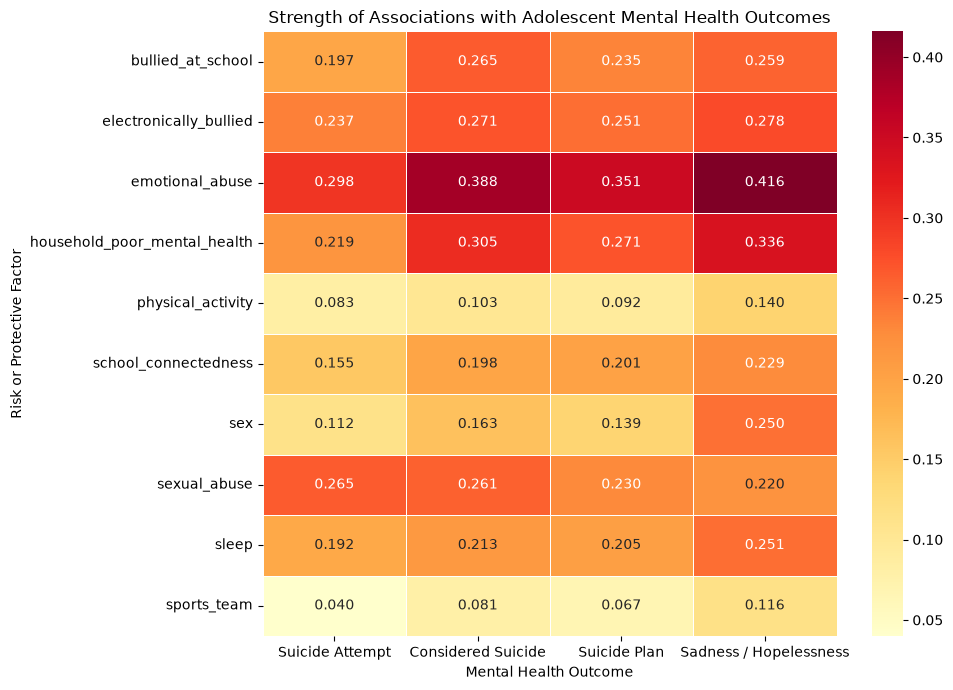

In [31]:
# Add suicide-attempt results to the multi-outcome results

attempt_heatmap_results = attempt_results_df.copy()
attempt_heatmap_results["Outcome"] = "attempted_at_least_once"

heatmap_results = pd.concat(
    [
        all_outcome_results[["Outcome", "Factor", "Cramer's V"]],
        attempt_heatmap_results[["Outcome", "Factor", "Cramer's V"]]
    ],
    ignore_index=True
)

# Create factor x outcome matrix
cramers_heatmap = heatmap_results.pivot(
    index="Factor",
    columns="Outcome",
    values="Cramer's V"
)

# Rename outcomes for readability
cramers_heatmap = cramers_heatmap.rename(
    columns={
        "persistent_sadness_hopelessness": "Sadness / Hopelessness",
        "considered_suicide": "Considered Suicide",
        "made_suicide_plan": "Suicide Plan",
        "attempted_at_least_once": "Suicide Attempt"
    }
)

# Plot heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    cramers_heatmap,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    linewidths=0.5
)

plt.title("Strength of Associations with Adolescent Mental Health Outcomes")
plt.xlabel("Mental Health Outcome")
plt.ylabel("Risk or Protective Factor")
plt.tight_layout()

plt.show()

### Heatmap Interpretation

The Cramér's V heatmap shows a consistent pattern across adolescent mental-health outcomes. Emotional abuse had the strongest association across all four outcomes and was particularly strongly associated with persistent sadness or hopelessness and seriously considering suicide.

Household poor mental health, electronic bullying, bullying at school, and sexual abuse also showed consistently elevated associations across multiple outcomes.

Sleep and school connectedness showed moderate associations across the mental-health outcomes, supporting their potential relevance as modifiable or protective factors. Physical activity and sports participation showed comparatively weaker associations.

Overall, the visualization reinforces the broader statistical findings: adverse childhood and household experiences and bullying show the strongest and most consistent relationships with adolescent mental-health outcomes, while several school and behavioral factors may represent additional intervention opportunities.

## Key Findings

* Mental-health concerns were common in the national YRBSS sample. Approximately 40.7% of respondents with valid data reported persistent sadness or hopelessness, 21.3% seriously considered suicide, 17.5% made a suicide plan, and 10.4% reported at least one suicide attempt.

* Female respondents reported substantially higher levels of persistent sadness or hopelessness, suicidal ideation, suicide planning, and suicide attempts than male respondents. Age differences were comparatively modest among the larger 14- to 17-year-old groups.

* Adverse childhood and household experiences showed some of the strongest relationships with adolescent mental-health outcomes. **Emotional abuse was the strongest and most consistent factor across all four outcomes examined**, with Cramér's V values of 0.416 for persistent sadness or hopelessness, 0.388 for considering suicide, 0.351 for making a suicide plan, and 0.298 for attempting suicide.

* Household poor mental health was also consistently associated with worse outcomes, including relatively strong associations with persistent sadness or hopelessness (V = 0.336) and considering suicide (V = 0.305). Sexual abuse was particularly notable for suicide attempts (V = 0.265).

* Bullying represented another consistent risk pattern. Electronic bullying and bullying at school were associated with persistent sadness or hopelessness, suicidal ideation, suicide planning, and suicide attempts. Electronic bullying generally showed slightly stronger associations than in-school bullying.

* Several adverse experiences also showed clear exposure gradients. Persistent sadness or hopelessness generally increased as emotional abuse, physical abuse, exposure to intimate partner violence, and school absence due to safety concerns became more frequent.

* School connectedness and sleep emerged as potentially important protective or modifiable factors. Stronger school connectedness was associated with lower prevalence of persistent sadness or hopelessness, while sadness or hopelessness declined from 64.1% among respondents reporting four or fewer hours of sleep to 25.2% among those reporting eight hours.

* Sleep remained associated with all four mental-health outcomes, with Cramér's V values ranging from 0.192 for suicide attempts to 0.251 for persistent sadness or hopelessness. School connectedness also showed consistent associations across outcomes, although its effect sizes were smaller than those observed for the strongest adverse-experience variables.

* Physical activity and sports-team participation generally corresponded with lower levels of persistent sadness or hopelessness, but their statistical associations were comparatively weak. Sports-team participation had the weakest association with suicide attempts among the selected factors (V = 0.040).

* The Cramér's V heatmap reinforced the overall pattern across outcomes: **adverse childhood experiences, household mental-health conditions, and bullying formed the strongest and most consistent cluster of associations**, while sleep and school connectedness occupied a middle tier of potentially modifiable factors and physical activity and sports participation showed weaker relationships.

* Because the national YRBSS sample is large, nearly all tested relationships reached statistical significance. Cramér's V was therefore used alongside chi-square tests to compare the relative strength of associations rather than relying on p-values alone.

Overall, the national YRBSS analysis suggests that adolescent mental-health outcomes are most strongly associated with adverse childhood experiences, household mental-health conditions, and bullying. School connectedness and sleep also show consistent relationships with mental health and may represent more actionable targets for prevention or early intervention. These national findings provide a behavioral and risk-factor framework that can later be interpreted alongside geographic YRBSS results and the project's healthcare-access, school-resource, and community-level datasets.


In [32]:
# FINAL_NOTEBOOK_TRANSFER_HELPER

import nbformat
from pathlib import Path
from copy import deepcopy

analysis_dir = Path("../Data_Analysis_Notebooks")
final_path = Path("../Final_Data_Analysis/07_full_project_analysis.ipynb")

source_files = [
    analysis_dir / "01_nsch_data_analysis.ipynb",
    analysis_dir / "02_acs_data_analysis.ipynb",
    analysis_dir / "03_nces_fiscal_data_analysis.ipynb",
    analysis_dir / "04_nces_nonfiscal_data_analysis.ipynb",
    analysis_dir / "05_hpsa_data_analysis.ipynb",
    analysis_dir / "06_yrbss_data_analysis.ipynb",
]

combined_cells = []

for source_path in source_files:

    with open(source_path, "r", encoding="utf-8") as f:
        source_nb = nbformat.read(f, as_version=4)

    for cell in source_nb.cells:

        # Keep transfer-helper cells out of the final notebook
        if (
            cell.cell_type == "code"
            and "FINAL_NOTEBOOK_TRANSFER_HELPER" in cell.source
        ):
            continue

        combined_cells.append(deepcopy(cell))

final_nb = nbformat.v4.new_notebook()
final_nb.cells = combined_cells

with open(final_path, "w", encoding="utf-8") as f:
    nbformat.write(final_nb, f)

print("FINAL NOTEBOOK UPDATED SUCCESSFULLY")
print("Total cells copied:", len(combined_cells))
print("Saved to:", final_path.resolve())
print()
print("Included:")
print("✓ NSCH")
print("✓ ACS")
print("✓ NCES Fiscal")
print("✓ NCES Nonfiscal")
print("✓ HPSA")
print("✓ YRBSS National")

FINAL NOTEBOOK UPDATED SUCCESSFULLY
Total cells copied: 260
Saved to: C:\Users\akila\pediatric-mental-health-analysis\notebooks\Final_Data_Analysis\07_full_project_analysis.ipynb

Included:
✓ NSCH
✓ ACS
✓ NCES Fiscal
✓ NCES Nonfiscal
✓ HPSA
✓ YRBSS National
